In [2]:
import sys
!python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plot
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [4]:
df  =pd.read_csv("C:/Users/hp/OneDrive/Desktop/Project github/@git i uploaded project/Best Projects for Data Analyst Portfolio/Business Intelligence Projects/SQL Projects/E-commerce Customer Behavior Analysis.csv")

DATA CLEANING

In [6]:
df.dropna(inplace=True)

In [9]:
df.fillna(0,inplace=True)

In [10]:
df.drop_duplicates()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ORD-10823,2025-12-31,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal
1996,ORD-10896,2025-12-31,Ayumi Dubois,Consumer,France,Europe,Clothing & Accessories,Cotton Formal Shirt,11,59.27,5,619.37,20.94,272.44,PayPal
1997,ORD-11148,2025-12-31,Barbara Jones,Consumer,Spain,Europe,Technology,Webcam HD 1080p,6,31.79,15,162.13,15.19,42.03,Bank Transfer
1998,ORD-11519,2025-12-31,Maria Suzuki,Home Office,Spain,Europe,Clothing & Accessories,Sports Water Bottle 750ml,5,9.50,5,45.12,14.25,7.12,Credit Card


In [12]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

EXPLARATORY DATA ANALYSIS

In [11]:
df.head()
df.info()
df.tail()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
std,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593
min,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000


In [19]:
import matplotlib.pyplot as plt

In [21]:
df  =pd.read_csv("C:/Users/hp/OneDrive/Desktop/Project github/@git i uploaded project/Best Projects for Data Analyst Portfolio/Business Intelligence Projects/SQL Projects/E-commerce Customer Behavior Analysis.csv")

In [26]:
# KPI Metrics
total_sales = df['Total_Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
total_quantity = df['Quantity'].sum()

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)


Total Sales: 484559.34
Total Profit: 158872.32
Total Orders: 2000
Total Quantity: 7115


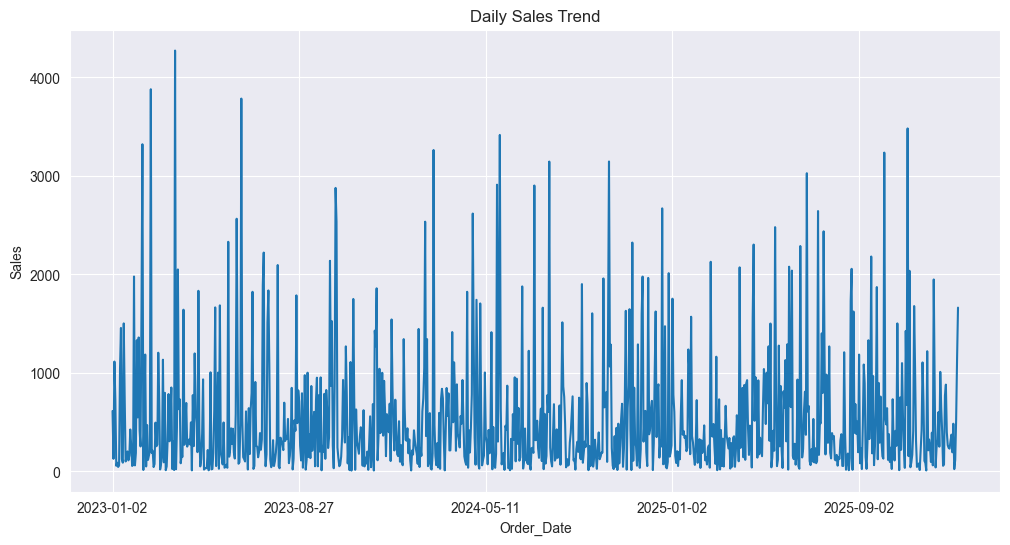

In [27]:
# --------------------------
# Sales Trend
# --------------------------
sales_trend = df.groupby('Order_Date')['Total_Sales'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title('Daily Sales Trend')
plt.ylabel('Sales')
plt.show()

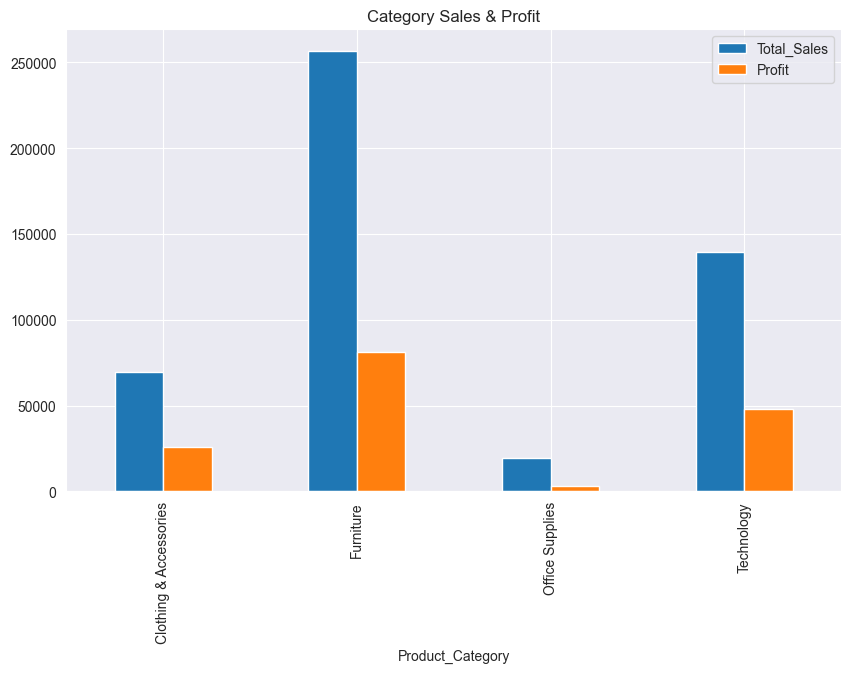

In [28]:
# --------------------------
# Category Performance
# --------------------------
category_sales = df.groupby('Product_Category')[['Total_Sales','Profit']].sum()

category_sales.plot(kind='bar', figsize=(10,6))
plt.title('Category Sales & Profit')
plt.show()

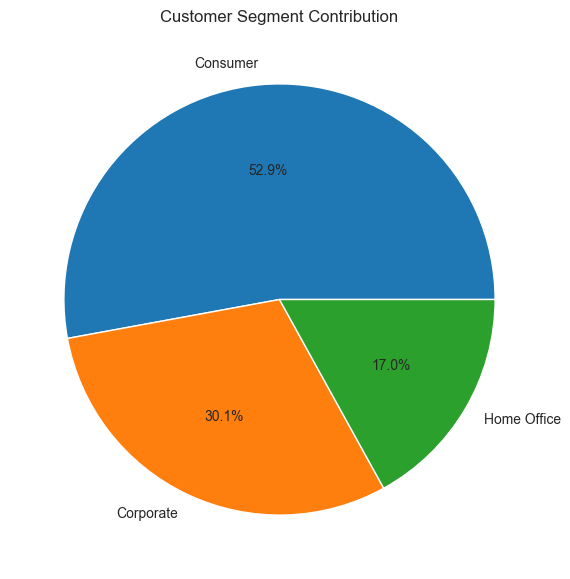

In [29]:
# --------------------------
# Customer Segment
# --------------------------
segment_sales = df.groupby('Customer_Segment')['Total_Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%')
plt.title('Customer Segment Contribution')
plt.show()

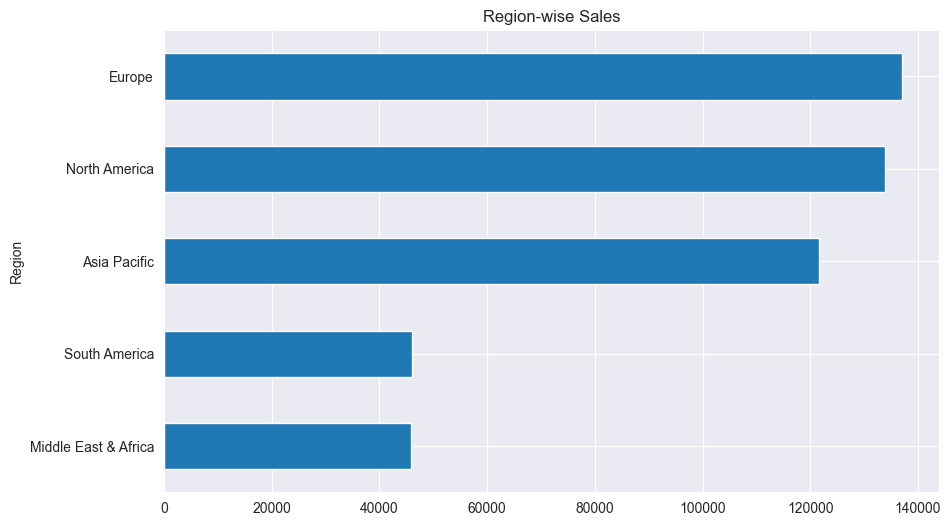

In [30]:
# --------------------------
# Region Sales
# --------------------------
region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values()

region_sales.plot(kind='barh', figsize=(10,6))
plt.title('Region-wise Sales')
plt.show()

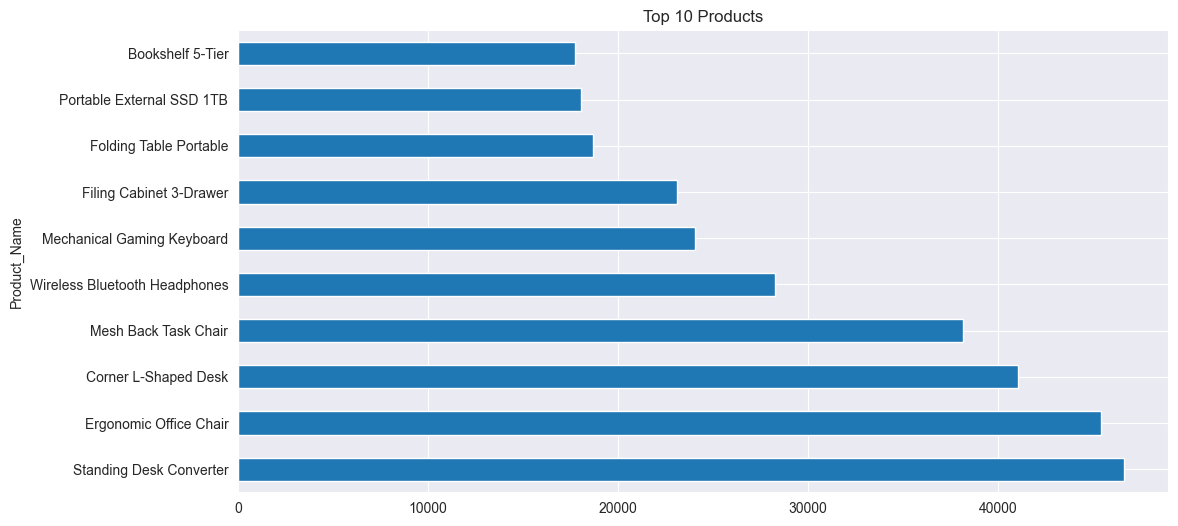

In [31]:
# --------------------------
# Top Products
# --------------------------
top_products = df.groupby('Product_Name')['Total_Sales'].sum().nlargest(10)

top_products.plot(kind='barh', figsize=(12,6))
plt.title('Top 10 Products')
plt.show()

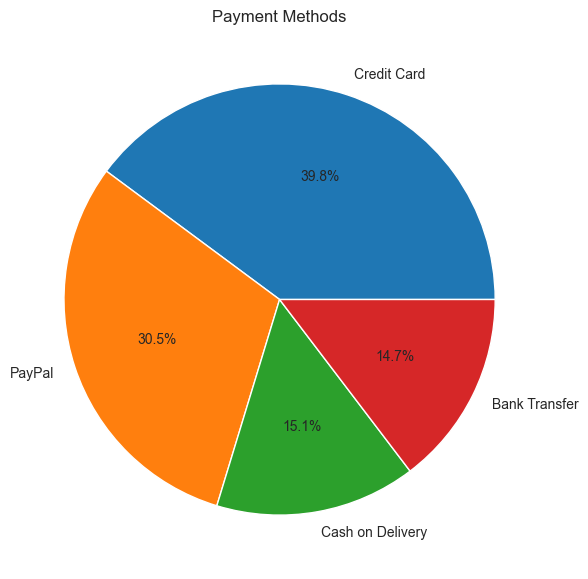

In [32]:
# --------------------------
# Payment Methods
# --------------------------
payment = df['Payment_Method'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment, labels=payment.index, autopct='%1.1f%%')
plt.title('Payment Methods')
plt.show()

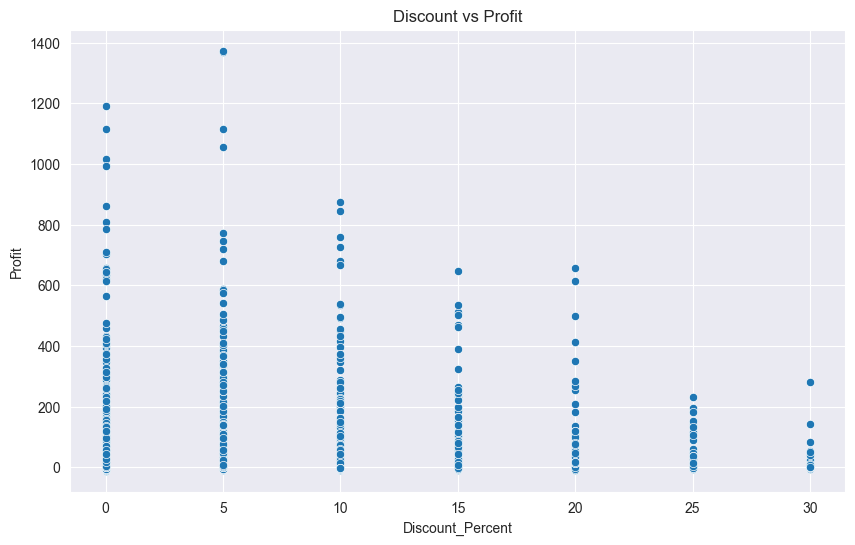

In [33]:

# --------------------------
# Discount vs Profit
# --------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,
                x='Discount_Percent',
                y='Profit')
plt.title('Discount vs Profit')
plt.show()


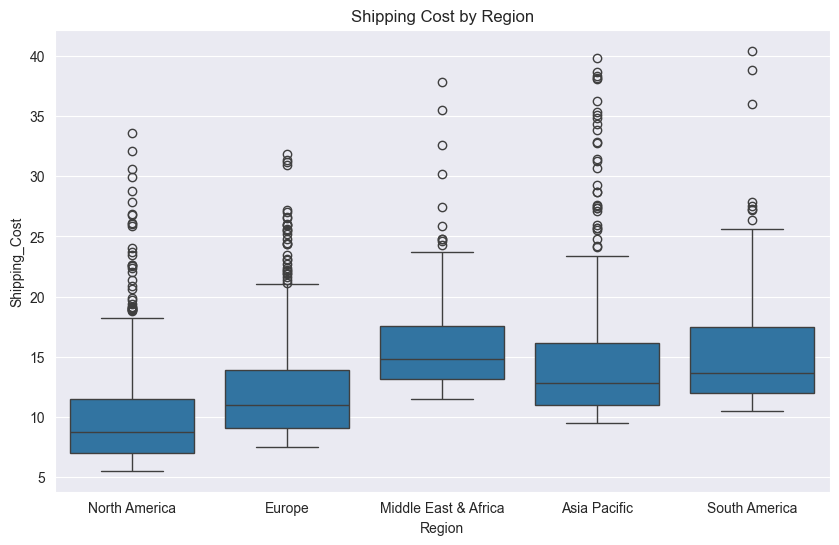

In [34]:
# --------------------------
# Shipping Cost
# --------------------------
plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x='Region',
            y='Shipping_Cost')
plt.title('Shipping Cost by Region')
plt.show()